# Методы кластеризации
---


In [1]:
# ============================================================
# Подготовка окружения: импорты и воспроизводимость
# ============================================================

# --- стандартные библиотеки ---
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Функция для фиксации зерна случайности
# ------------------------------------------------------------
def set_seed(seed: int = 111):
    random.seed(seed)
    np.random.seed(seed)


SEED = 111
set_seed(SEED)

print("Окружение готово, seed зафиксирован.")


Окружение готово, seed зафиксирован.


---

## Загрузка датасета MNIST с Hugging Face

Почему именно MNIST?

- это реальные данные, а не полностью искусственный пример;
- размер выборки большой (десятки тысяч объектов), но ещё адекватный для экспериментов в ноутбуке;
- есть «настоящие» метки цифр, по которым удобно оценивать качество кластеризации (ARI, NMI и т.п.),  
  но при обучении кластеризаторов мы эти метки не используем;
- признаки — пиксели изображений, то есть это пример высокомерного пространства,
  с которым часто приходится иметь дело в задачах машинного обучения.

Далее будем:

- брать только изображения как вход для алгоритмов кластеризации;
- использовать метки цифр **только для оценки**, а не для обучения.


In [2]:
# ============================================================
# Загрузка датасета MNIST
# ============================================================

from datasets import load_dataset

HF_CACHE_DIR = "./hf_cache"

dataset = load_dataset(
    "mnist",
    cache_dir=HF_CACHE_DIR,
)

print(dataset)

# В MNIST есть два сплита: 'train' и 'test'
ds_train = dataset["train"]
ds_test = dataset["test"]

# В pandas-формат для удобства анализа
df_train = ds_train.to_pandas()
df_test = ds_test.to_pandas()

print("Размер train (строки, колонки):", df_train.shape)
print("Размер test  (строки, колонки):", df_test.shape)
print("\nПервые строки train:")
df_train.head()


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
Размер train (строки, колонки): (60000, 2)
Размер test  (строки, колонки): (10000, 2)

Первые строки train:


,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,4
3,"{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...",1
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,9


---

## Подготовка данных MNIST для кластеризации

В этом блоке:

- возьмём подвыборку изображений из train-части;
- превратим изображения в числовую матрицу признаков;
- отдельно сохраним истинные метки цифр (для оценки качества, но не для обучения).


In [3]:
# ============================================================
# Подготовка подвыборки MNIST и матрицы признаков X
# ============================================================

# Возьмём не весь train, а подвыборку, чтобы алгоритмы работали быстрее
N_TRAIN = 10_000

# Подвыборка из df_train (pandas), фиксируем random_state для воспроизводимости
ds_sample = ds_train.shuffle(seed=SEED).select(range(N_TRAIN))

print("Размер подвыборки:", len(ds_sample))

X_list = []
y_true_list = []

for item in ds_sample:
    img = item["image"]          # это объект PIL.Image.Image
    label = item["label"]

    arr = np.array(img, dtype=np.float32)  # (28, 28)
    X_list.append(arr.reshape(-1))         # решейп в одномерный вектор (784,)

    y_true_list.append(label)

X = np.stack(X_list, axis=0)               # shape: (N_TRAIN, 784)
y_true = np.array(y_true_list)

print("Форма матрицы признаков X:", X.shape)
print("Форма вектора меток y_true:", y_true.shape)

Размер подвыборки: 10000
Форма матрицы признаков X: (10000, 784)
Форма вектора меток y_true: (10000,)


---

## Быстрый просмотр подвыборки MNIST

В этом блоке:

- посмотрим на несколько изображений из `ds_sample`;
- проверим распределение цифр в подвыборке.


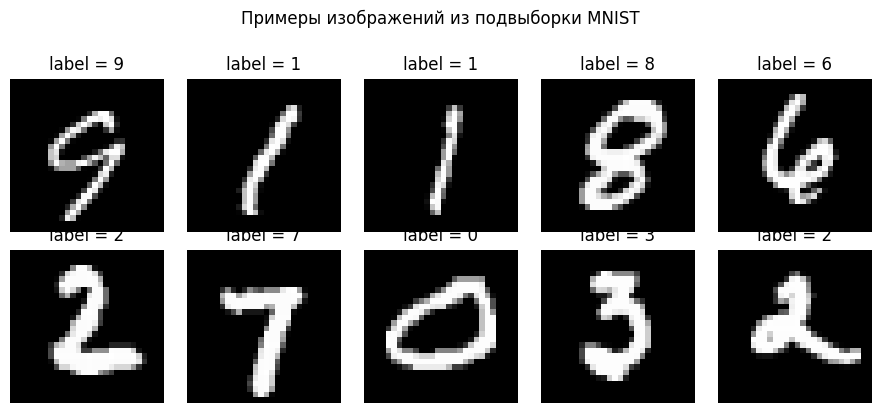

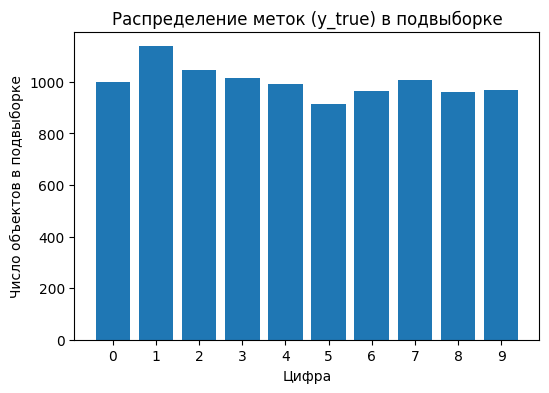

Распределение меток: Counter({np.int64(1): 1137, np.int64(2): 1045, np.int64(3): 1013, np.int64(7): 1007, np.int64(0): 998, np.int64(4): 992, np.int64(9): 968, np.int64(6): 966, np.int64(8): 962, np.int64(5): 912})


In [4]:
# ============================================================
# Визуальный просмотр нескольких изображений и распределения меток
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter

# Покажем несколько первых объектов из подвыборки
n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols, 2.0 * n_rows))

axes = axes.ravel()

for ax, item in zip(axes, ds_sample):
    img = np.array(item["image"], dtype=np.float32)
    label = item["label"]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"label = {label}")
    ax.axis("off")

plt.suptitle("Примеры изображений из подвыборки MNIST", y=1.02)
plt.tight_layout()
plt.show()

# Распределение цифр в подвыборке
label_counts = Counter(y_true)
labels_sorted = sorted(label_counts.keys())
counts_sorted = [label_counts[d] for d in labels_sorted]

plt.figure(figsize=(6, 4))
plt.bar(labels_sorted, counts_sorted)
plt.xlabel("Цифра")
plt.ylabel("Число объектов в подвыборке")
plt.title("Распределение меток (y_true) в подвыборке")
plt.xticks(labels_sorted)
plt.show()

print("Распределение меток:", label_counts)


---

## Подготовка признаков для кластеризации (масштабирование)

Сейчас у нас есть матрица признаков `X` формы `(N_TRAIN, 784)`:

- каждая строка — одна картинка цифры;
- каждый столбец — яркость конкретного пикселя (значения от 0 до 255).

Алгоритмы кластеризации, которые опираются на расстояния (например, k-means),
чувствительны к масштабу признаков. В нашем случае все признаки — пиксели,
и они уже в одном диапазоне, но стандартная практика в табличных данных —
масштабировать признаки к нулевому среднему и единичному стандартному отклонению.

Здесь мы:

- применим `StandardScaler` к матрице `X`;
- получим `X_scaled` и будем подавать его в алгоритмы кластеризации.


In [5]:
# ============================================================
# Масштабирование признаков для кластеризации
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Форма X_scaled:", X_scaled.shape)
print("Среднее по признакам :", X_scaled.mean(axis=0)[:50])
print("STD по признакам :     ", X_scaled.std(axis=0)[:50])


Форма X_scaled: (10000, 784)
Среднее по признакам : [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  1.2013137e-06  3.6243358e-07
  7.5859873e-07 -1.1635689e-06  8.7732298e-07  2.4696664e-07
  1.9504856e-07 -6.3882209e-07 -1.2100898e-07  1.2908653e-07
 -5.5116453e-07 -5.1580741e-08 -1.6759373e-07 -3.5054646e-07
 -3.4973621e-07 -8.9406939e-07]
STD по признакам :      [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.      

Масштабирование сработало корректно. Матрица сохранила форму (10 000 × 784), средние значений признаков стали близки к нулю, стандартные отклонения «живых» пикселей — близки к 1. Нулевые СКО у первых признаков означают, что это константные пиксели (обычно фон по краям изображения), они одинаковы у всех объектов и не влияют на расстояния при кластеризации.

---

## Метрики кластеризации и логирование результатов

Прежде чем запускать алгоритмы, подготовим "инфраструктуру":

- заведём словарь `cluster_results` для всех моделей;
- напишем функцию `log_cluster_results(...)`, которая:
  - получает `X_scaled` и метки кластера,
  - считает базовые метрики,
  - сохраняет их в словарь.

Метрики, которые будем использовать:

- `n_clusters` — сколько кластеров реально получилось у алгоритма;
- `silhouette` — внутренняя метрика: насколько объекты ближе к "своему" кластеру,
  чем к соседнему (чем ближе к 1, тем лучше разделены кластеры);
  
- `ari` (Adjusted Rand Index) — сравнивает кластеры с истинными метками,
  учитывая совпадения и несовпадения пар объектов (1 — полное совпадение,
  около 0 — примерно как случайное разбиение);
- `nmi` (Normalized Mutual Information) — ещё одна мера согласия кластеров
  с истинными метками, нормированная взаимная информация (1 — полное совпадение).

Этих  показателей достаточно, чтобы сравнивать разные алгоритмы
на одном и том же MNIST.

In [6]:
# ============================================================
# Метрики кластеризации и логирование результатов
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

cluster_results: dict[str, dict] = {}


def log_cluster_results(
    model_name: str,
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray | None = None,
):
    """
    Считаем базовые метрики кластеризации и сохраняем их
    в словарь cluster_results под ключом model_name.
    """

    metrics = {}

    # базовая информация
    unique_labels = np.unique(labels)
    metrics["n_clusters"] = len(unique_labels)

    # внутренняя метрика (использует только X и labels)
    if metrics["n_clusters"] > 1 and len(X) > metrics["n_clusters"]:
        metrics["silhouette"] = silhouette_score(X, labels)
    else:
        metrics["silhouette"] = np.nan

    # внешние метрики (если есть "настоящие" метки y_true)
    if y_true is not None:
        metrics["ari"] = adjusted_rand_score(y_true, labels)
        metrics["nmi"] = normalized_mutual_info_score(y_true, labels)
    else:
        metrics["ari"] = np.nan
        metrics["nmi"] = np.nan

    cluster_results[model_name] = metrics
    return metrics


def results_to_dataframe(results: dict) -> pd.DataFrame:
    """Переводим словарь результатов в DataFrame для удобства сравнений."""
    if not results:
        return pd.DataFrame()

    df_res = pd.DataFrame.from_dict(results, orient="index")
    return df_res.sort_index()


cluster_results.clear()
print("Логирование метрик готово.")


Логирование метрик готово.


---

## Первая модель: k-means на MNIST

Начнём с базового централизованного метода — k-means.

Что мы тут делаем?

- работаем в пространстве `X_scaled` (10 000 объектов × 784 признака);
- задаём число кластеров `k = 10`, по количеству цифр в MNIST;
- запускаем `KMeans` и получаем метки кластеров `labels_kmeans`;
- считаем метрики через `log_cluster_results(...)`:
  - сколько кластеров реально получилось;
  - значение силуэта;
  - согласие с настоящими цифрами (ARI, NMI);
- смотрим итоговую таблицу `cluster_results`.


In [9]:
# ============================================================
# Первая модель кластеризации: KMeans на X_scaled
# ============================================================

from sklearn.cluster import KMeans

K_INIT = 10  # число кластеров, по количеству цифр

kmeans = KMeans(
    n_clusters=K_INIT,
    random_state=SEED,
    n_init="auto",
)

labels_kmeans = kmeans.fit_predict(X_scaled)

print("Форма массива меток кластеров:", labels_kmeans.shape)
print("Уникальные кластеры:", np.unique(labels_kmeans))

# Логируем метрики
log_cluster_results("KMeans (k=10)", X_scaled, labels_kmeans, y_true=y_true)

# Смотрим таблицу результатов
results_to_dataframe(cluster_results)

Форма массива меток кластеров: (10000,)
Уникальные кластеры: [0 1 2 3 4 5 6 7 8 9]


,n_clusters,silhouette,ari,nmi
KMeans (k=10),10,-0.021635,0.269576,0.404002


---

## Визуализация результата k-means

Здесь хочется понять, *что именно* нашёл k-means:

- сколько объектов попало в каждый кластер;
- на какие "типичные" цифры похожи центры кластеров.


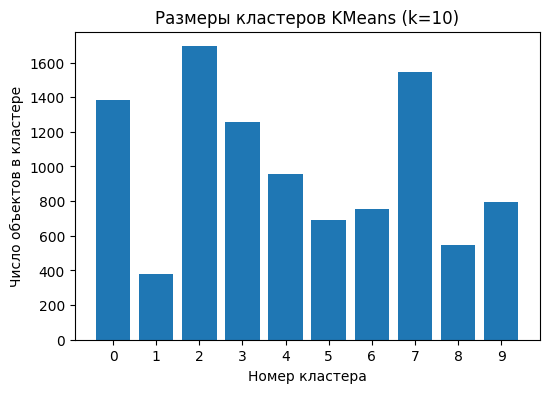

Размеры кластеров: Counter({np.int32(2): 1693, np.int32(7): 1545, np.int32(0): 1384, np.int32(3): 1257, np.int32(4): 954, np.int32(9): 796, np.int32(6): 757, np.int32(5): 690, np.int32(8): 547, np.int32(1): 377})


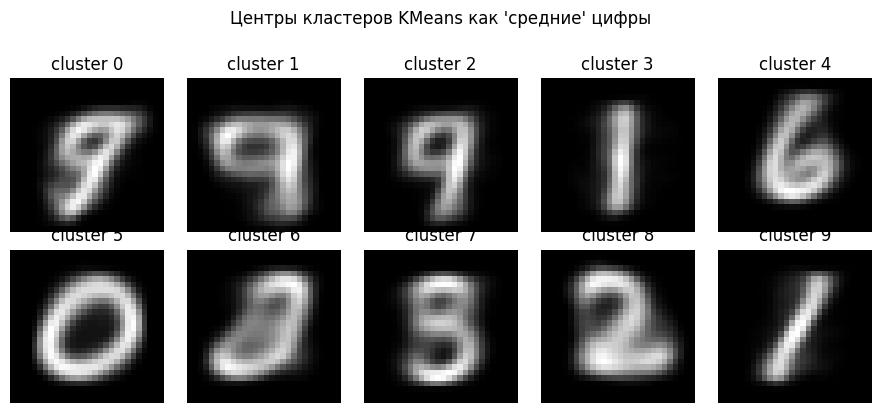

In [10]:
# ============================================================
# Визуализация результатов KMeans:
#   1) размер кластеров
#   2) центры кластеров как "средние цифры"
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter

# 1. Размеры кластеров
label_counts = Counter(labels_kmeans)
clusters_sorted = sorted(label_counts.keys())
counts_sorted = [label_counts[c] for c in clusters_sorted]

plt.figure(figsize=(6, 4))
plt.bar(clusters_sorted, counts_sorted)
plt.xlabel("Номер кластера")
plt.ylabel("Число объектов в кластере")
plt.title("Размеры кластеров KMeans (k=10)")
plt.xticks(clusters_sorted)
plt.show()

print("Размеры кластеров:", label_counts)

# 2. Центры кластеров как изображения
# kmeans.cluster_centers_ сейчас в пространстве X_scaled -> вернёмся к пикселям
centers_scaled = kmeans.cluster_centers_               # shape: (10, 784)
centers_original = scaler.inverse_transform(centers_scaled)

# Ограничим значения диапазоном [0, 255] на всякий случай
centers_original = np.clip(centers_original, 0, 255)

centers_images = centers_original.reshape(K_INIT, 28, 28)

n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols, 2.0 * n_rows))
axes = axes.ravel()

for cluster_id, ax in enumerate(axes):
    img = centers_images[cluster_id]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"cluster {cluster_id}")
    ax.axis("off")

plt.suptitle("Центры кластеров KMeans как 'средние' цифры", y=1.02)
plt.tight_layout()
plt.show()


Центры кластеров k-means действительно похожи на цифры: есть кластеры, где центр выглядит как «чистая» 0, 1, 2 и т.п. — значит, туда попали в основном однотипные изображения. Есть и размытые центры, похожие сразу на две цифры: там в одном кластере смешались разные варианты написания. То есть k-means не «угадывает цифру по номеру», а находит набор типичных прототипов написания, иногда чистых, иногда смешанных.

---

## KMeans при разных значениях k

Раньше мы запустили k-means с `k = 10`, опираясь на знание предметной области 
(в MNIST 10 цифр). Но это всего лишь гиперпараметр, а не истина.

Здесь посмотрим, как меняются метрики при разных значениях `k`:

- переберём несколько значений `k` (например, 8, 10, 12);
- для каждого `k` запустим k-means на `X_scaled`;
- посчитаем `silhouette`, `ari`, `nmi` через `log_cluster_results(...)`;
- сравним результаты в одной таблице.

Идея: посмотреть, даёт ли именно `k = 10` лучший баланс метрик, 
или какое-то другое число кластеров описывает структуру данных не хуже (или даже лучше).


In [11]:
# ============================================================
# KMeans при разных значениях k: 8, 10, 12
# ============================================================

from sklearn.cluster import KMeans

k_values = [8, 10, 12]

for k in k_values:
    model_name = f"KMeans (k={k})"

    kmeans_k = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init="auto",
    )
    labels_k = kmeans_k.fit_predict(X_scaled)

    log_cluster_results(model_name, X_scaled, labels_k, y_true=y_true)

# Смотрим только строки с KMeans
df_kmeans = results_to_dataframe(cluster_results)
df_kmeans.loc[[name for name in df_kmeans.index if name.startswith("KMeans")]]


,n_clusters,silhouette,ari,nmi
KMeans (k=10),10,-0.021635,0.269576,0.404002
KMeans (k=12),12,0.010636,0.345254,0.461876
KMeans (k=8),8,-0.007931,0.299849,0.409608


---

## Визуализация кластеров KMeans в 2D с помощью PCA

Хочется увидеть кластеры "как обычно" — точки на плоскости, раскрашенные по цветам.

Проблема: сейчас у нас 784 признака (пикселя), а на графике только две оси.

Поэтому сделаем технический шаг:

- применим PCA из `sklearn`, чтобы спроецировать `X_scaled` в пространство 2 компонент; (PCA (Principal Component Analysis) — это метод уменьшения размерности данных, который преобразует коррелированные переменные в набор некоррелированных главных компонент.)
- это просто проекция, которая старается сохранить как можно больше разброса данных;
- сами кластеры не пересчитываются, мы только смотрим на них в 2D.

Сделаем два графика:

- раскраска по настоящим цифрам (`y_true`);
- раскраска по кластерам KMeans (`labels_kmeans`).


Форма X_2d: (10000, 2)


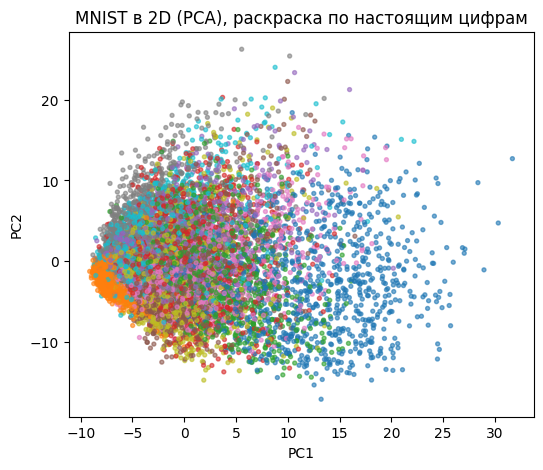

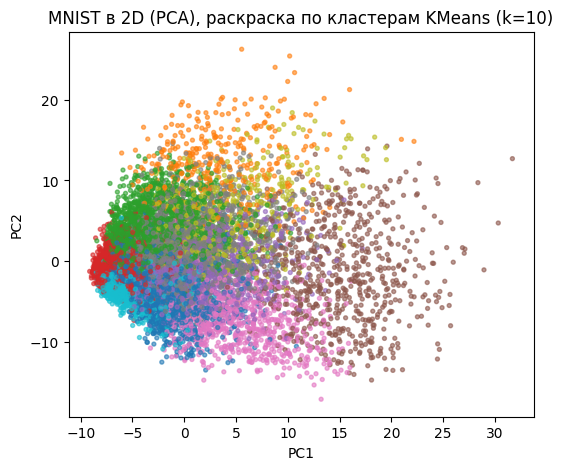

In [12]:
# ============================================================
# PCA до 2 компонент и визуализация: цифры vs кластеры KMeans
# ============================================================

from sklearn.decomposition import PCA

# Проекция X_scaled в 2D для визуализации
pca_2 = PCA(n_components=2, random_state=SEED)
X_2d = pca_2.fit_transform(X_scaled)

print("Форма X_2d:", X_2d.shape)

# 1) Раскраска по настоящим цифрам
plt.figure(figsize=(6, 5))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_true,
    s=8,
    cmap="tab10",
    alpha=0.6,
)
plt.title("MNIST в 2D (PCA), раскраска по настоящим цифрам")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 2) Раскраска по кластерам KMeans (k=10)
plt.figure(figsize=(6, 5))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_kmeans,
    s=8,
    cmap="tab10",
    alpha=0.6,
)
plt.title("MNIST в 2D (PCA), раскраска по кластерам KMeans (k=10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


**Как читать эти картинки.**  
PCA сжало исходное пространство до двух компонент, поэтому каждая точка — цифра в координатах (PC1, PC2). 
Вверху цвет = настоящая цифра, внизу цвет = кластер k-means. 
Сильное перекрытие цветов на верхнем графике означает, что разные цифры часто лежат в одних и тех же областях. 
На нижнем графике видно, как k-means разрезает это облако на 10 областей: часть кластеров попадает в более-менее однородные зоны, 
часть смешивает несколько цифр — отсюда невысокие ARI/NMI и отрицательный силуэт.

---

## Иерархическая кластеризация (Agglomerative, 10 кластеров)

Теперь возьмём агломеративный метод:

- алгоритм строит иерархию слияний (дендрограмму);
- мы задаём `n_clusters = 10`, то есть фактически выбираем высоту "среза" дерева;
- работаем в том же пространстве `X_scaled`, что и k-means;
- считаем те же метрики (`silhouette`, `ari`, `nmi`);
- на проекции PCA в 2D сравниваем разбиение с k-means.


In [13]:
# ============================================================
# AgglomerativeClustering на X_scaled (10 кластеров)
# ============================================================

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=10,
    linkage="ward",
)

labels_agg = agg.fit_predict(X_scaled)

print("Форма массива меток кластеров:", labels_agg.shape)
print("Уникальные кластеры:", np.unique(labels_agg))

# Логируем метрики
log_cluster_results("Agglomerative (k=10)", X_scaled, labels_agg, y_true=y_true)

# Смотрим KMeans vs Agglomerative
df_results = results_to_dataframe(cluster_results)
df_results.loc[
    [name for name in df_results.index
     if name in ("KMeans (k=10)", "Agglomerative (k=10)")]
]


Форма массива меток кластеров: (10000,)
Уникальные кластеры: [0 1 2 3 4 5 6 7 8 9]


,n_clusters,silhouette,ari,nmi
Agglomerative (k=10),10,-0.032962,0.372908,0.515514
KMeans (k=10),10,-0.021635,0.269576,0.404002


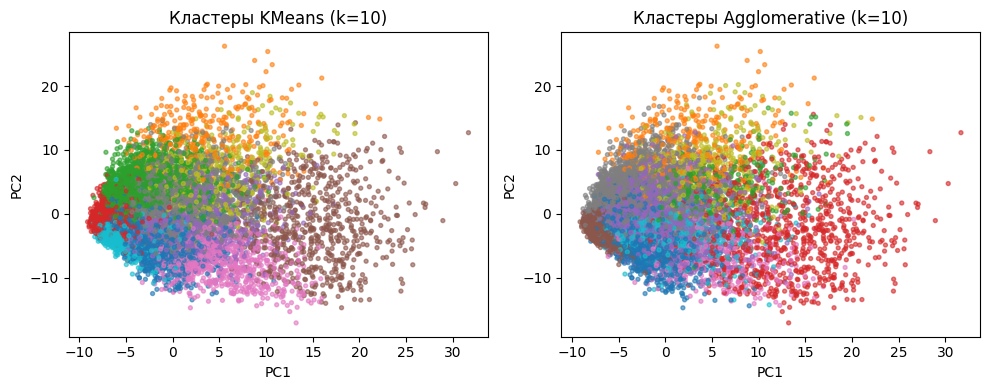

In [14]:
# ============================================================
# Визуализация: KMeans vs Agglomerative на проекции PCA(2)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_kmeans,
    s=8,
    cmap="tab10",
    alpha=0.6,
)
axes[0].set_title("Кластеры KMeans (k=10)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels_agg,
    s=8,
    cmap="tab10",
    alpha=0.6,
)
axes[1].set_title("Кластеры Agglomerative (k=10)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


**Вывод.**  
Оба метода работают в тех же 784-мерных пиксельных признаках, и по силуэту это видно: 
значения слегка отрицательные и у k-means, и у иерархического метода — кластеры в целом 
сильно перекрываются, хорошо отделённых «островков» почти нет.

При этом Agglomerative (с срезом на 10 кластеров и связью Ward) заметно лучше согласуется 
с настоящими цифрами: ARI и NMI выше, чем у k-means. То есть дерево слияний удаётся 
разрезать так, чтобы в кластерах оказалось больше однородных цифр, пусть и ценой 
ещё меньшей геометрической разделённости.

На проекции PCA это видно по характеру раскраски: k-means даёт более регулярные «ленты» 
и области, а иерархический метод разбивает облако на куски, лучше подстраиваясь под 
реальную структуру данных, хотя границы между цветами всё равно остаются размытыми.


---

## Смесь гауссовских распределений (GaussianMixture, 10 компонент)

Следующий подход — вероятностная модель кластеров.

Для честного сравнения с k-means и агломеративной кластеризацией:

- берём `n_components = 10` (по числу цифр);
- обучаем `GaussianMixture` на `X_scaled`;
- по предсказанным меткам считаем те же метрики (`silhouette`, `ari`, `nmi`)
  и добавляем их в `cluster_results`.


In [15]:
# ============================================================
# GaussianMixture на X_scaled (10 компонент) с регуляризацией
# ============================================================

from sklearn.mixture import GaussianMixture

# Для стабильности GMM лучше работать с float64
X_gmm = X_scaled.astype(np.float64)

gmm = GaussianMixture(
    n_components=10,
    covariance_type="full",   # своя ковариационная матрица у каждой компоненты
    reg_covar=1e-6,           # маленькая добавка к диагонали ковариации, чтобы она не вырождалась
    init_params="kmeans",     # стартуем с центров k-means
    random_state=SEED,
    max_iter=200,
)

gmm.fit(X_gmm)
labels_gmm = gmm.predict(X_gmm)

print("Форма массива меток кластеров:", labels_gmm.shape)
print("Уникальные кластеры:", np.unique(labels_gmm))

# Логируем метрики
log_cluster_results("GaussianMixture (k=10)", X_gmm, labels_gmm, y_true=y_true)

# Сравниваем три метода: KMeans, Agglomerative, GMM
df_results = results_to_dataframe(cluster_results)
df_results.loc[
    [
        "KMeans (k=10)",
        "Agglomerative (k=10)",
        "GaussianMixture (k=10)",
    ]
]


Форма массива меток кластеров: (10000,)
Уникальные кластеры: [0 1 2 3 4 5 6 7 8 9]


,n_clusters,silhouette,ari,nmi
KMeans (k=10),10,-0.021635,0.269576,0.404002
Agglomerative (k=10),10,-0.032962,0.372908,0.515514
GaussianMixture (k=10),10,-0.027681,0.267507,0.399153


**Вывод по трём методам.**  
Для сырых пикселей MNIST и фиксированного `k = 10` все три подхода дают довольно слабое разделение: 
силуэт чуть отрицательный, значит, кластеры сильно перекрываются. 
Агломеративная кластеризация лучше всего согласуется с настоящими цифрами (самые высокие ARI и NMI), 
k-means и смесь гауссовских распределений дают похожий уровень качества. 
Это нормальный результат: без учителя и без специальной подготовки признаков 
кластеризация MNIST не превращается в полноценную замену классификатора.


---

## Плотностная кластеризация: DBSCAN на 2D-проекции

DBSCAN работает не через "центры" кластеров, а через плотность точек:

На полном пространстве из 784 признаков DBSCAN практически бесполезен: оценивать локальную плотность
в такой размерности трудно. Поэтому для иллюстрации запустим его на 2D-проекции `X_2d` из PCA:

- сами кластеры считаем по `X_2d`;
- метрики (`silhouette`, `ari`, `nmi`) считаем в тех же координатах `X_2d`;
- на графике покажем кластеры и точки, ушедшие в шум.


In [16]:
# ============================================================
# DBSCAN на 2D-проекции (PCA) и метрики
# ============================================================

from sklearn.cluster import DBSCAN
from collections import Counter


dbscan = DBSCAN(
    eps=2.5,        # радиус окрестности
    min_samples=10  # сколько соседей нужно для "ядра" кластера
)

labels_dbscan = dbscan.fit_predict(X_2d)

unique_labels = np.unique(labels_dbscan)
print("Уникальные метки DBSCAN:", unique_labels)

counts = Counter(labels_dbscan)
print("Размеры кластеров (включая шум -1):", counts)

# Логируем метрики (X = X_2d, потому что именно в этих координатах ищем плотные области)
log_cluster_results("DBSCAN (PCA2)", X_2d, labels_dbscan, y_true=y_true)

df_results = results_to_dataframe(cluster_results)
df_results.loc[
    [
        "KMeans (k=10)",
        "Agglomerative (k=10)",
        "GaussianMixture (k=10)",
        "DBSCAN (PCA2)",
    ]
]


Уникальные метки DBSCAN: [-1  0]
Размеры кластеров (включая шум -1): Counter({np.int64(0): 9980, np.int64(-1): 20})


,n_clusters,silhouette,ari,nmi
KMeans (k=10),10,-0.021635,0.269576,0.404002
Agglomerative (k=10),10,-0.032962,0.372908,0.515514
GaussianMixture (k=10),10,-0.027681,0.267507,0.399153
DBSCAN (PCA2),2,0.610384,0.000014,0.002224


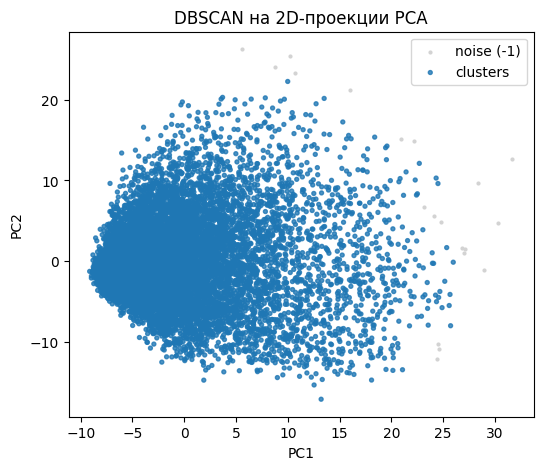

In [17]:
# ============================================================
# Визуализация кластеров DBSCAN на PCA(2)
# ============================================================

mask_noise = labels_dbscan == -1
mask_cluster = ~mask_noise

plt.figure(figsize=(6, 5))

# Шумовые точки отдельным цветом
plt.scatter(
    X_2d[mask_noise, 0],
    X_2d[mask_noise, 1],
    s=4,
    c="lightgray",
    label="noise (-1)",
)

# Остальные точки раскрасим по кластерам
plt.scatter(
    X_2d[mask_cluster, 0],
    X_2d[mask_cluster, 1],
    c=labels_dbscan[mask_cluster],
    s=8,
    cmap="tab10",
    alpha=0.8,
    label="clusters",
)

plt.title("DBSCAN на 2D-проекции PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="best")
plt.show()


**DBSCAN на исходных пикселях.**  
В 784-мерном пространстве локальную плотность отличить почти невозможно, 
поэтому при разных `eps` алгоритм либо даёт один кластер, либо почти всё помечает как шум. 
Это пример того, что плотностные методы плохо масштабируются по размерности признаков 
и требуют либо понижения размерности, либо другого представления данных.


На проекции PCA(2) DBSCAN фактически находит один большой кластер и немного шума. 
Алгоритм хорошо отделяет плотную "основную массу" от отдельных точек на периферии, 
но никакой осмысленной структуры внутри этой массы не видит. 
Поэтому внутренний силуэт получается высоким, а внешние метрики (ARI, NMI) 
почти нулевые: такое разбиение никак не совпадает с реальными цифрами.


---

## Итог: сравнение алгоритмов кластеризации на MNIST

Соберём все полученные результаты в одну таблицу и посмотрим:

- сколько кластеров вернул каждый метод;
- каков средний силуэт;
- насколько кластеры согласуются с настоящими цифрами (ARI и NMI).

После этого для алгоритма с лучшим совпадением с цифрами 
построим таблицу `кластер × цифра`, чтобы увидеть, какие кластеры «чистые»,
а какие содержат смесь разных классов.


In [18]:
# ============================================================
# Итоговая таблица по всем моделям
# ============================================================

df_results_full = results_to_dataframe(cluster_results)
df_results_full


,n_clusters,silhouette,ari,nmi
Agglomerative (k=10),10,-0.032962,0.372908,0.515514
DBSCAN (PCA2),2,0.610384,0.000014,0.002224
GaussianMixture (k=10),10,-0.027681,0.267507,0.399153
KMeans (k=10),10,-0.021635,0.269576,0.404002
KMeans (k=12),12,0.010636,0.345254,0.461876
KMeans (k=8),8,-0.007931,0.299849,0.409608


In [19]:
# Отсортируем методы по ARI (внешняя метрика, ближе к 1 — лучше)
df_results_sorted = df_results_full.sort_values(by="ari", ascending=False)
df_results_sorted


,n_clusters,silhouette,ari,nmi
Agglomerative (k=10),10,-0.032962,0.372908,0.515514
KMeans (k=12),12,0.010636,0.345254,0.461876
KMeans (k=8),8,-0.007931,0.299849,0.409608
KMeans (k=10),10,-0.021635,0.269576,0.404002
GaussianMixture (k=10),10,-0.027681,0.267507,0.399153
DBSCAN (PCA2),2,0.610384,0.000014,0.002224


In [20]:
# Берём имя лучшего метода по ARI
best_model_name = df_results_sorted.index[0]
best_model_name


'Agglomerative (k=10)'

In [21]:
# ============================================================
# Таблица "кластер × настоящая цифра" для лучшего метода
# ============================================================

import pandas as pd

# Подбираем labels в зависимости от имени модели
if best_model_name == "KMeans (k=10)":
    best_labels = labels_kmeans
elif best_model_name == "Agglomerative (k=10)":
    best_labels = labels_agg
elif best_model_name == "GaussianMixture (k=10)":
    best_labels = labels_gmm
elif best_model_name == "DBSCAN (PCA2)":
    best_labels = labels_dbscan
else:
    raise ValueError(f"Не знаем, какие метки соответствуют модели: {best_model_name}")

df_best = pd.DataFrame({
    "true": y_true,
    "cluster": best_labels,
})

crosstab = pd.crosstab(df_best["cluster"], df_best["true"])
crosstab


true,0,1,2,3,4,5,6,7,8,9
cluster,,,,,,,,,,
0,10,10,12,10,45,367,6,389,365,238
1,3,0,23,42,78,12,0,159,23,82
2,8,3,141,1,13,0,259,3,0,1
3,856,0,24,1,9,11,33,3,25,2
4,7,15,445,705,17,395,36,8,455,30
5,0,1097,2,1,7,0,0,2,5,0
6,14,1,191,136,6,18,0,1,5,2
7,0,5,32,11,792,9,2,441,14,601
8,10,1,152,102,9,89,7,1,61,12


- На сырых пикселях MNIST (784 признака) ни один алгоритм не превращается в «хороший классификатор».  
   Средний силуэт у всех методов немного отрицательный — кластеры сильно перекрываются, 
   хорошо отделённых областей в пространстве признаков почти нет.
- Таблица «кластер × цифра» показывает типичную картину для кластеризации без учителя:
   есть кластеры почти чисто под одну цифру (0, 1, 6), есть кластеры-свалки с несколькими близкими цифрами,
   а одна и та же цифра может быть размазана по нескольким кластерам из-за разных стилей написания.

В целом на этом примере видно, что кластеризация:
- не восстанавливает «правильные классы» автоматически;
- чувствительна к выбору расстояния, числа кластеров и самого семейства алгоритма;
- даёт полезные группы и прототипы, но их всегда нужно интерпретировать и проверять вручную, 
  особенно в задачах с высокой размерностью и пересекающимися классами.


# Кластеризация табличного датасета Iris с Hugging Face

Используем датасет Iris с четырьмя числовыми признаками:

In [22]:
# ============================================================
# Загрузка табличного датасета Iris с Hugging Face
# ============================================================

from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 111
set_seed(SEED)

HF_CACHE_DIR = "./hf_cache"

dataset = load_dataset(
    "scikit-learn/iris",
    cache_dir=HF_CACHE_DIR,
)

# Обычно в iris один сплит 'train'
ds = dataset["train"]
df = ds.to_pandas()

print("Форма датафрейма:", df.shape)
df.head()


Форма датафрейма: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [23]:
# ============================================================
# Признаки и настоящие метки для Iris из HF
# ============================================================

from collections import Counter

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
target_col = "Species"

# Признаки
X = df[feature_cols].to_numpy()

# Переводим виды Iris из строк в числа 0,1,2
species_unique = sorted(df[target_col].unique())
species_to_int = {name: idx for idx, name in enumerate(species_unique)}
print("Кодировка видов:", species_to_int)

y_true = df[target_col].map(species_to_int).to_numpy()

print("Форма X:", X.shape)
print("Форма y_true:", y_true.shape)
print("Уникальные метки:", np.unique(y_true))

# Баланс классов в числах
counts_int = Counter(y_true)
print("\nБаланс классов (по кодам):", counts_int)

# Баланс классов с именами видов
counts_named = df[target_col].value_counts()
print("\nБаланс классов (по видам):")
print(counts_named)


Кодировка видов: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
Форма X: (150, 4)
Форма y_true: (150,)
Уникальные метки: [0 1 2]

Баланс классов (по кодам): Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})

Баланс классов (по видам):
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


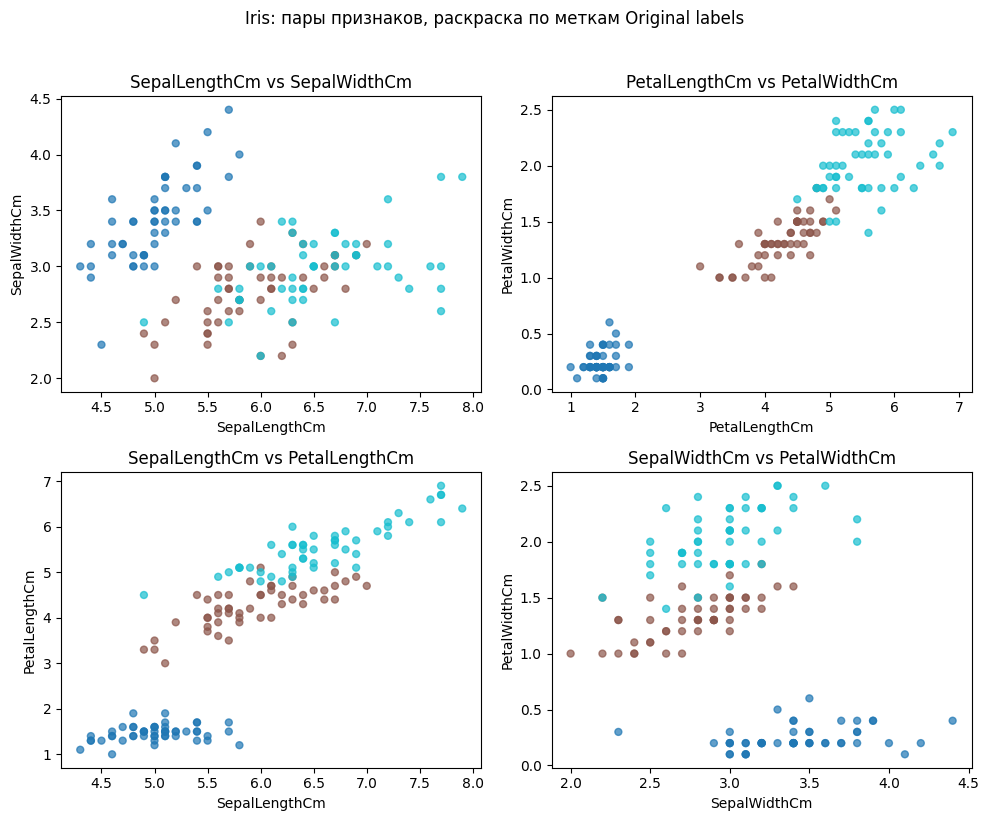

In [24]:
# ============================================================
# Визуализация разных пар признаков Iris в одной фигуре
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def show_features(labels, title_suffix=""):
    labels = np.asarray(labels)

    feature_pairs = [
        ("SepalLengthCm", "SepalWidthCm"),
        ("PetalLengthCm", "PetalWidthCm"),
        ("SepalLengthCm", "PetalLengthCm"),
        ("SepalWidthCm", "PetalWidthCm"),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    
    for ax, (fx, fy) in zip(axes, feature_pairs):
        x = df[fx].to_numpy()
        y = df[fy].to_numpy()

        if (labels == -1).any():
            # режим для DBSCAN: шум отдельным цветом
            mask_noise = labels == -1
            mask_cluster = ~mask_noise

            ax.scatter(
                x[mask_noise],
                y[mask_noise],
                c="lightgray",
                s=25,
                label="noise (-1)",
            )
            sc = ax.scatter(
                x[mask_cluster],
                y[mask_cluster],
                c=labels[mask_cluster],
                s=25,
                cmap="tab10",
                alpha=0.7,
                label="clusters",
            )
        else:
            sc = ax.scatter(
                x, y,
                c=labels,
                s=25,
                cmap="tab10",
                alpha=0.7,
            )

        ax.set_xlabel(fx)
        ax.set_ylabel(fy)
        ax.set_title(f"{fx} vs {fy}")
    
    fig.suptitle(f"Iris: пары признаков, раскраска по меткам {title_suffix}", y=1.02)
    plt.tight_layout()
    plt.show()

show_features(y_true, "Original labels")

In [25]:
# ============================================================
# Масштабирование признаков и метрики кластеризации
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Форма X_scaled:", X_scaled.shape)

cluster_results: dict[str, dict] = {}


def log_cluster_results(
    model_name: str,
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray | None = None,
):
    metrics = {}

    unique_labels = np.unique(labels)
    metrics["n_clusters"] = len(unique_labels)

    # внутренняя метрика
    if metrics["n_clusters"] > 1 and len(X) > metrics["n_clusters"]:
        metrics["silhouette"] = silhouette_score(X, labels)
    else:
        metrics["silhouette"] = np.nan

    # внешние метрики
    if y_true is not None:
        metrics["ari"] = adjusted_rand_score(y_true, labels)
        metrics["nmi"] = normalized_mutual_info_score(y_true, labels)
    else:
        metrics["ari"] = np.nan
        metrics["nmi"] = np.nan

    cluster_results[model_name] = metrics
    return metrics


def results_to_dataframe(results: dict) -> pd.DataFrame:
    if not results:
        return pd.DataFrame()
    df_res = pd.DataFrame.from_dict(results, orient="index")
    return df_res.sort_index()


cluster_results.clear()
print("Инфраструктура для метрик готова.")


Форма X_scaled: (150, 4)
Инфраструктура для метрик готова.


In [29]:
# ============================================================
# KMeans (k=3) на Iris
# ============================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,   # по числу видов
    random_state=SEED,
    n_init="auto",
)

labels_kmeans = kmeans.fit_predict(X_scaled)

log_cluster_results("KMeans (k=3)", X_scaled, labels_kmeans, y_true=y_true)

results_to_dataframe(cluster_results)


,n_clusters,silhouette,ari,nmi
KMeans (k=3),3,0.478724,0.428951,0.587378


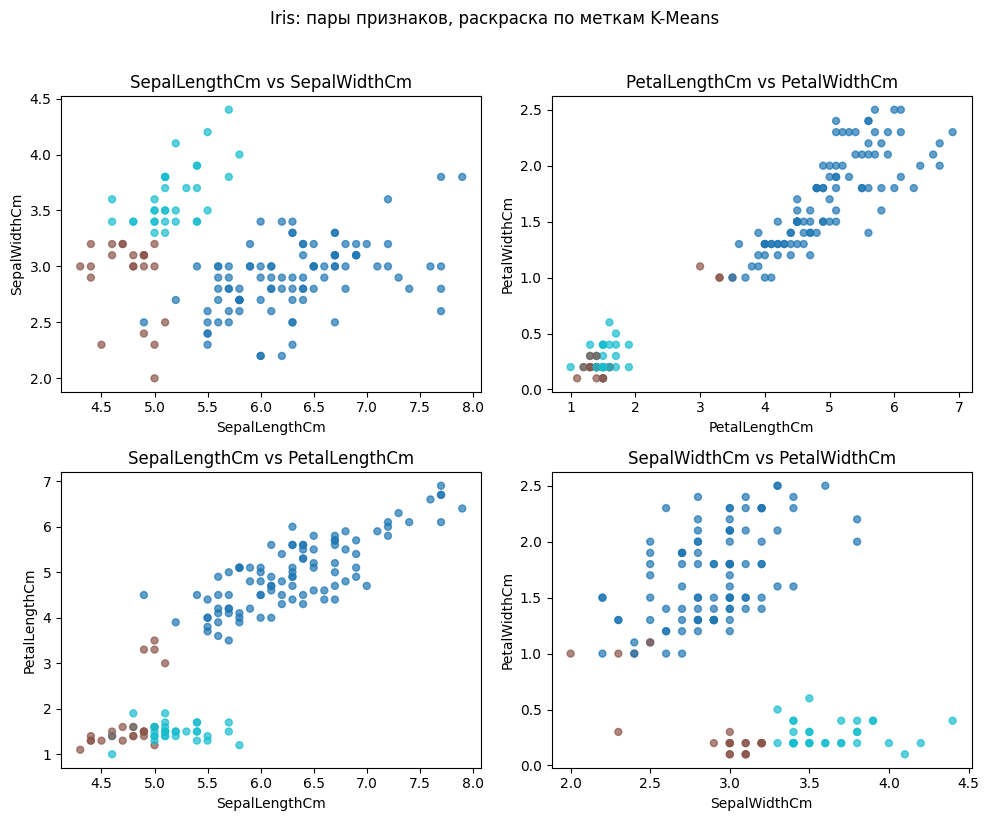

In [30]:
show_features(labels_kmeans, "K-Means")

In [34]:
# ============================================================
# AgglomerativeClustering (Ward, k=3)
# ============================================================

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward",  # минимальный прирост внутрикластерного разброса при слиянии
)

labels_agg = agg.fit_predict(X_scaled)

log_cluster_results("Agglomerative (k=3)", X_scaled, labels_agg, y_true=y_true)

results_to_dataframe(cluster_results)


,n_clusters,silhouette,ari,nmi
Agglomerative (k=3),3,0.445540,0.615323,0.675470
KMeans (k=3),3,0.478724,0.428951,0.587378


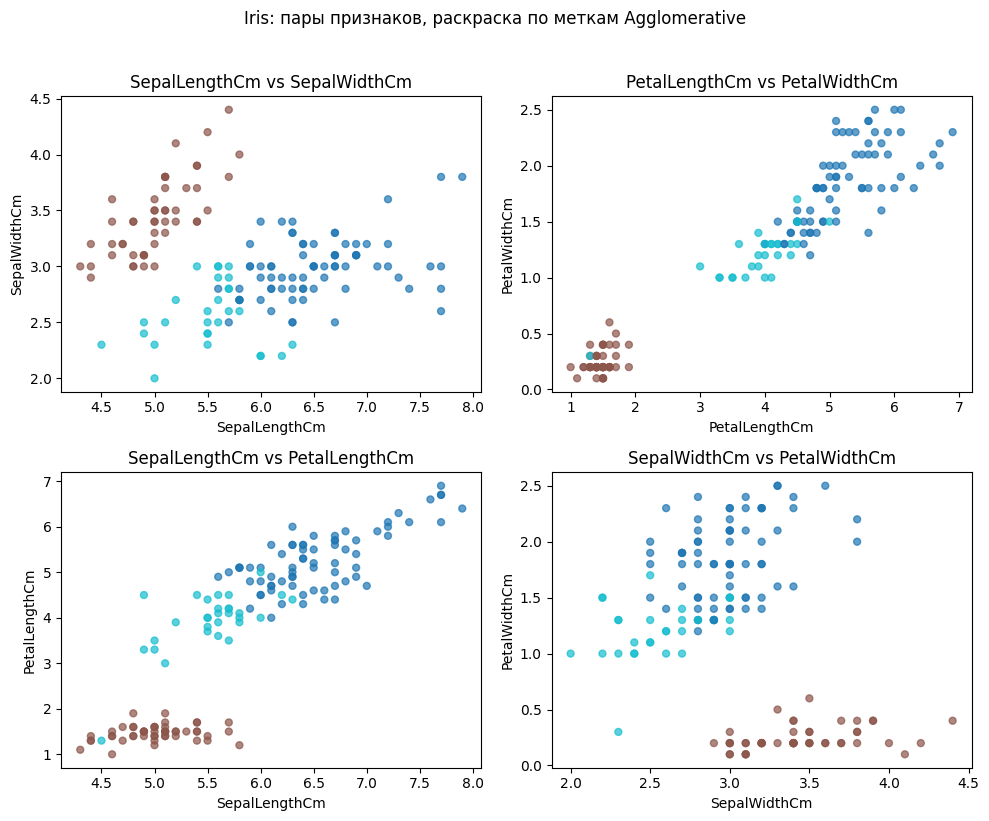

In [32]:
# Визуализация: Agglomerative

show_features(labels_agg, "Agglomerative")

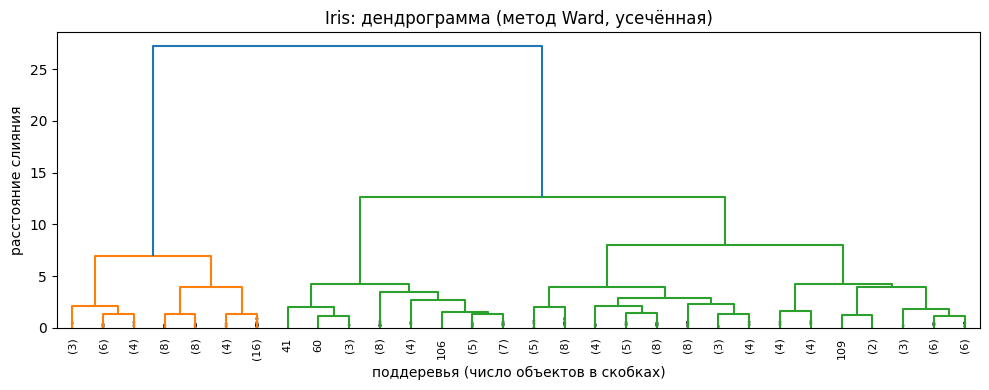

In [35]:
# ============================================================
# Дендрограмма для Iris (агломеративная кластеризация, Ward)
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 4))

dendrogram(
    Z,
    truncate_mode="lastp",      # показываем только последние p слияний (укороченное дерево)
    p=30,                       # количество "листьев" после усечения
    show_contracted=True,       # для усечённых веток внизу пишем размер кластера в скобках
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.title("Iris: дендрограмма (метод Ward, усечённая)")
plt.xlabel("поддеревья (число объектов в скобках)")
plt.ylabel("расстояние слияния")
plt.tight_layout()
plt.show()


**Вывод по дендрограмме.**  
Внизу показаны укрупнённые поддеревья: подпись вида `(3)`, `(4)` означает, 
что в этой ветке собрано 3 или 4 исходных объекта.
«число без скобок» — это просто одиночный объект (кластер из одной точки). (так сказать ID кластера)

Хорошо видно, что одна группа (setosa) отделяется от остальных уже на низких уровнях:
её поддеревья сливаются между собой, но долго не соединяются с другими ветками. 
Две оставшиеся группы (versicolor и virginica) объединяются в одно большое поддерево 
и сливаются между собой только на более высокой высоте. 
Если мысленно провести горизонтальный срез дерева в районе перед самым крупным слиянием, 
получим ровно три кластера — то же число групп, что и у настоящих видов Iris.


In [36]:
# ============================================================
# GaussianMixture (k=3)
# ============================================================

from sklearn.mixture import GaussianMixture

X_gmm = X_scaled.astype(np.float64)

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    reg_covar=1e-6,
    init_params="kmeans",
    random_state=SEED,
)

gmm.fit(X_gmm)
labels_gmm = gmm.predict(X_gmm)

log_cluster_results("GaussianMixture (k=3)", X_gmm, labels_gmm, y_true=y_true)

results_to_dataframe(cluster_results)


,n_clusters,silhouette,ari,nmi
Agglomerative (k=3),3,0.445540,0.615323,0.675470
GaussianMixture (k=3),3,0.409184,0.507349,0.680722
KMeans (k=3),3,0.478724,0.428951,0.587378


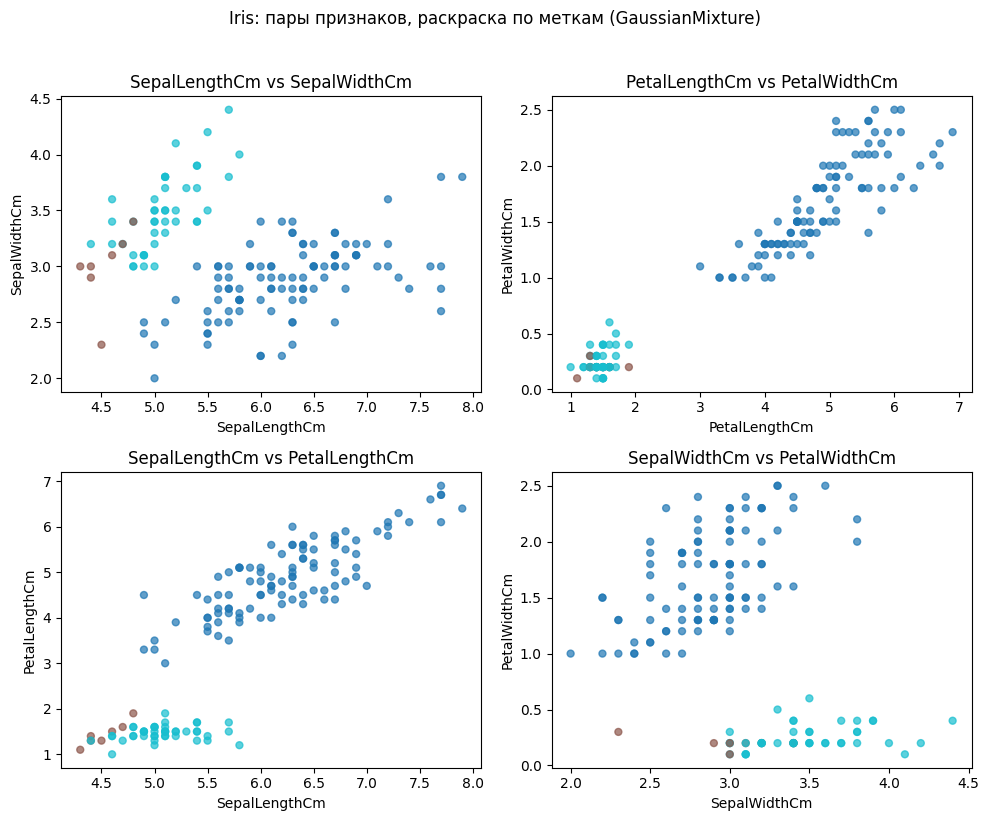

In [37]:
show_features(labels_gmm, title_suffix="(GaussianMixture)")

In [42]:
# ============================================================
# DBSCAN
# ============================================================

from sklearn.cluster import DBSCAN
from collections import Counter

dbscan = DBSCAN(
    eps=1,      # радиус окрестности в стандартизованных признаках
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)

counts = Counter(labels_dbscan)
print("Распределение меток (включая шум -1):", counts)

log_cluster_results("DBSCAN", X_scaled, labels_dbscan, y_true=y_true)

results_to_dataframe(cluster_results)


Распределение меток (включая шум -1): Counter({np.int64(1): 98, np.int64(0): 49, np.int64(-1): 3})


,n_clusters,silhouette,ari,nmi
Agglomerative (k=3),3,0.445540,0.615323,0.675470
DBSCAN,3,0.537098,0.553582,0.695616
GaussianMixture (k=3),3,0.409184,0.507349,0.680722
KMeans (k=3),3,0.478724,0.428951,0.587378


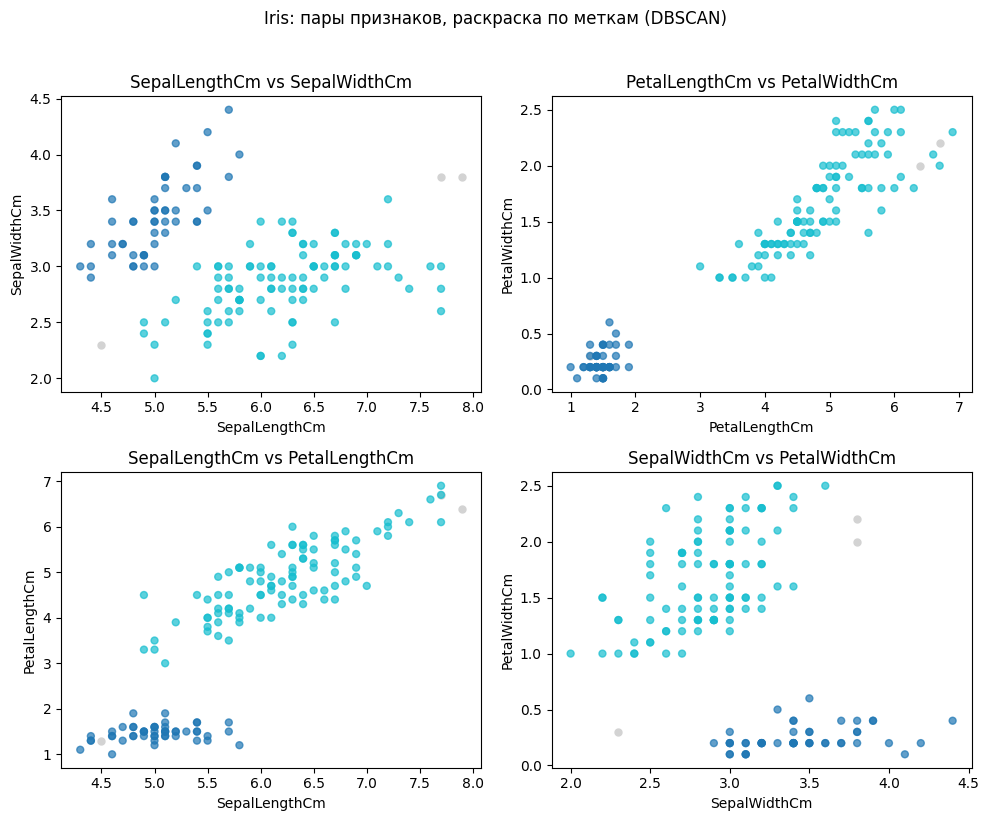

In [43]:
show_features(labels_dbscan, title_suffix="(DBSCAN)")

**Вывод по DBSCAN на Iris.**  
DBSCAN не знает, что в данных три вида, и не подгоняет ответ под число классов. 
Он ищет плотные области в пространстве признаков и объединяет в один кластер всё, 
что связано цепочками соседей в радиусе `eps`, а редкие точки помечает как шум.

На Iris при выбранных `eps` и `min_samples` алгоритм видит две плотные области:
отдельный компактный кластер (setosa) и один общий кластер для двух других видов, 
которые сильно перекрываются по признакам лепестков. Несколько точек на периферии 
не набирают нужного числа соседей и уходят в шум. 

In [44]:
# ============================================================
# Итоговая таблица по всем методам
# ============================================================

df_results_full = results_to_dataframe(cluster_results)
df_results_full


,n_clusters,silhouette,ari,nmi
Agglomerative (k=3),3,0.445540,0.615323,0.675470
DBSCAN,3,0.537098,0.553582,0.695616
GaussianMixture (k=3),3,0.409184,0.507349,0.680722
KMeans (k=3),3,0.478724,0.428951,0.587378


In [45]:
# Отсортируем по ARI (насколько кластеры совпадают с настоящими видами)
df_results_sorted = df_results_full.sort_values(by="ari", ascending=False)
df_results_sorted


,n_clusters,silhouette,ari,nmi
Agglomerative (k=3),3,0.445540,0.615323,0.675470
DBSCAN,3,0.537098,0.553582,0.695616
GaussianMixture (k=3),3,0.409184,0.507349,0.680722
KMeans (k=3),3,0.478724,0.428951,0.587378


In [46]:
# Берём лучший метод и смотрим "кластер × вид"
best_model_name = df_results_sorted.index[0]
best_model_name


'Agglomerative (k=3)'

In [47]:
if best_model_name == "KMeans (k=3)":
    best_labels = labels_kmeans
elif best_model_name == "Agglomerative (k=3)":
    best_labels = labels_agg
elif best_model_name == "GaussianMixture (k=3)":
    best_labels = labels_gmm
elif best_model_name == "DBSCAN":
    best_labels = labels_dbscan
else:
    raise ValueError(f"Неизвестная модель: {best_model_name}")

df_best = pd.DataFrame({
    "true": y_true,
    "cluster": best_labels,
})

pd.crosstab(df_best["cluster"], df_best["true"])


true,0,1,2
cluster,,,
0,0,23,48
1,49,0,0
2,1,27,2


**Вывод по разбиению Agglomerative (k=3).**

Если помнить кодировку видов (0 — setosa, 1 — versicolor, 2 — virginica), то:

- кластер 1 почти полностью соответствует setosa: 49 из 50 объектов → очень чистый кластер;
- кластер 2 в основном содержит versicolor (27 объектов), но туда же попадает один setosa и пара virginica;
- кластер 0 — смесь versicolor и virginica (23 и 48 объектов соответственно).

То есть иерархическая кластеризация уверенно выделяет setosa как отдельную, хорошо отделённую группу. 
Два остальных вида лежат близко друг к другу в признаках лепестков, поэтому алгоритм делит их область на два пересекающихся кластера и не может провести между ними чистую границу.
